<a href="https://colab.research.google.com/github/ganeshkumba/Explainable-AI/blob/main/EAI_ASS_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Setup & Google Drive Mount

In [33]:
# Install dependencies (uncomment if needed)
# !pip install imbalanced-learn xgboost shap lime pdpbox

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Google Drive Mount
from google.colab import drive
drive.mount('/content/drive')

# Load dataset (Update the path to your file inside Drive)
DATA_PATH = "/content/drive/MyDrive/lung_cancer_dataset.csv"
df = pd.read_csv(DATA_PATH)
print("Dataset loaded:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (50000, 11)


2. Exploratory Data Analysis (EDA)

   age  gender  pack_years radon_exposure  asbestos_exposure  \
0   69    Male   66.025244           High                  0   
1   32  Female   12.780800           High                  0   
2   89  Female    0.408278         Medium                  1   
3   78  Female   44.065232            Low                  0   
4   38  Female   44.432440         Medium                  1   

   secondhand_smoke_exposure  copd_diagnosis alcohol_consumption  \
0                          0               1            Moderate   
1                          1               1            Moderate   
2                          1               1                 NaN   
3                          1               0            Moderate   
4                          0               1                 NaN   

   family_history  lung_cancer  
0               0            0  
1               1            1  
2               0            1  
3               0            1  
4               1            1  

Missing

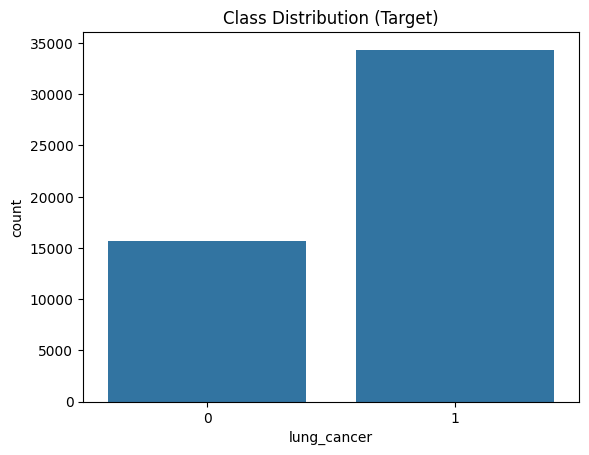

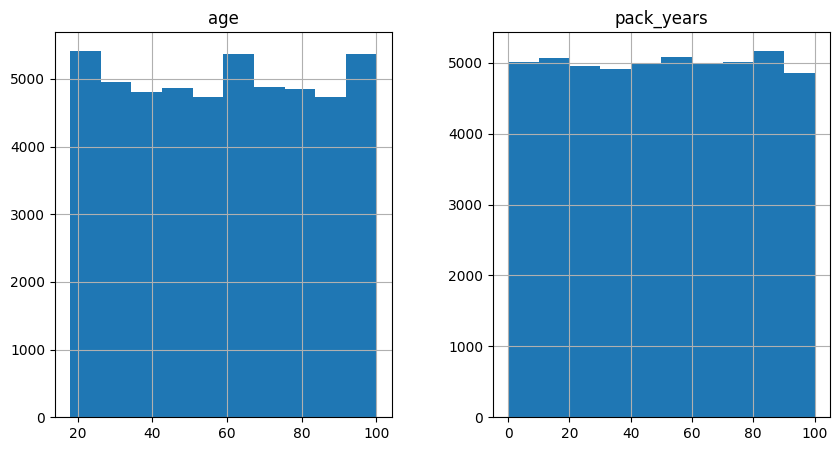

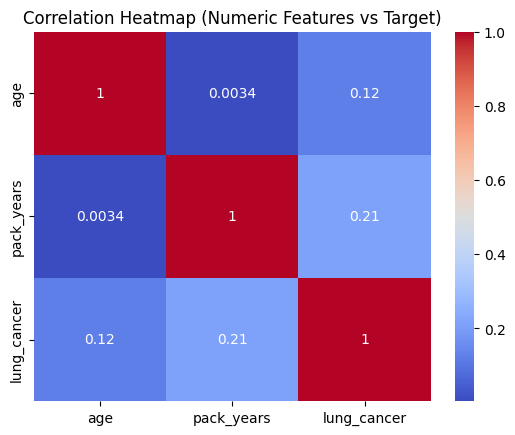

In [34]:
# Drop patient_id (not useful)
if "patient_id" in df.columns:
    df = df.drop(columns=["patient_id"])

# Encode Yes/No → 1/0
binary_map = {"Yes": 1, "No": 0}
for col in ["asbestos_exposure", "secondhand_smoke_exposure",
            "copd_diagnosis", "family_history", "lung_cancer"]:
    df[col] = df[col].map(binary_map)

# Preview dataset
print(df.head())

# Missing values
print("\nMissing values:\n", df.isnull().sum())

# Class balance
sns.countplot(x="lung_cancer", data=df)
plt.title("Class Distribution (Target)")
plt.show()

# Numeric distributions
num_cols = ["age", "pack_years"]
df[num_cols].hist(figsize=(10,5))
plt.show()

# Correlation heatmap (numeric + encoded binary target)
sns.heatmap(df[num_cols + ["lung_cancer"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features vs Target)")
plt.show()

3. Preprocessing

In [35]:
def preprocess_df(df, target="lung_cancer", enc_method='label', scaler='standard', smote=True):
    df_proc = df.copy()

    # Numeric & categorical
    num_cols = ["age", "pack_years"]
    cat_cols = [c for c in df_proc.columns if c not in num_cols + [target]]

    # Impute missing values
    num_imputer = SimpleImputer(strategy="median")
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df_proc[num_cols] = num_imputer.fit_transform(df_proc[num_cols])
    df_proc[cat_cols] = cat_imputer.fit_transform(df_proc[cat_cols])

    # Encode categoricals
    if enc_method == 'label':
        for col in cat_cols:
            le = LabelEncoder()
            df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    else:
        df_proc = pd.get_dummies(df_proc, columns=cat_cols, drop_first=True)

    # Scale numerics
    if scaler == 'standard':
        s = StandardScaler()
    else:
        s = MinMaxScaler()
    df_proc[num_cols] = s.fit_transform(df_proc[num_cols])

    # Split train/test
    X = df_proc.drop(columns=[target])
    y = df_proc[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

    # Handle imbalance
    if smote:
        from imblearn.over_sampling import SMOTE
        sm = SMOTE(random_state=42)
        X_train, y_train = sm.fit_resample(X_train, y_train)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = preprocess_df(df)
print(X_train.shape, X_test.shape)

(54982, 9) (10000, 9)


4. Machine Learning Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# Optimized models dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "SVM (Linear)": SVC(kernel="linear", probability=True, max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, algorithm="ball_tree", n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", n_jobs=-1, random_state=42)
}

# Evaluation function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = None
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob) if y_prob is not None else None
    }

# Training and evaluation
ml_results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    ml_results[name] = evaluate_model(model, X_test, y_test)

# Convert results to DataFrame
results_df = pd.DataFrame(ml_results).T

# Convert decimal → percentage format
results_df = results_df.applymap(lambda x: f"{x*100:.2f}%" if pd.notnull(x) else "N/A")

# Display final results table
print("\nMachine Learning Model Performance (in %):")
display(results_df)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training SVM (Linear)...


5. Deep Learning Models (Optimized)

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM, Input
from tensorflow.keras.callbacks import EarlyStopping

# Convert to numpy
Xtr, Xte = X_train.values, X_test.values
ytr, yte = y_train.values, y_test.values

# Early stopping to prevent long training
es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1)

# ----------------
# 5.1 MLP
# ----------------
mlp = Sequential([
    Dense(64, activation="relu", input_shape=(Xtr.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])
mlp.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
mlp.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=20, batch_size=32, callbacks=[es], verbose=1)

# ----------------
# 5.2 CNN
# ----------------
cnn = Sequential([
    Input(shape=(Xtr.shape[1],1)),
    Conv1D(32, 3, activation="relu"),
    Conv1D(64, 3, activation="relu"),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn.fit(Xtr.reshape(-1,Xtr.shape[1],1), ytr, validation_data=(Xte.reshape(-1,Xte.shape[1],1), yte),
        epochs=20, batch_size=32, callbacks=[es], verbose=1)

# ----------------
# 5.3 LSTM
# ----------------
lstm = Sequential([
    Input(shape=(Xtr.shape[1],1)),
    LSTM(64),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])
lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm.fit(Xtr.reshape(-1,Xtr.shape[1],1), ytr, validation_data=(Xte.reshape(-1,Xte.shape[1],1), yte),
         epochs=20, batch_size=32, callbacks=[es], verbose=1)

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6596 - loss: 0.6033 - val_accuracy: 0.6741 - val_loss: 0.5822
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6805 - loss: 0.5810 - val_accuracy: 0.6695 - val_loss: 0.5958
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6873 - loss: 0.5732 - val_accuracy: 0.6937 - val_loss: 0.5578
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6906 - loss: 0.5722 - val_accuracy: 0.6348 - val_loss: 0.6088
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6916 - loss: 0.5672 - val_accuracy: 0.6640 - val_loss: 0.5797
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6916 - loss: 0.5665 - val_accuracy: 0.6837 - val_loss: 0.5633
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6666 - loss: 0.5998 - val_accuracy: 0.6751 - val_loss: 0.5763
Epoc

6. Evaluate Deep Learning Models

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def eval_dl(model, X, y, name, reshape=False):
    if reshape:
        X = X.reshape(-1, X.shape[1], 1)
    y_prob = model.predict(X).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_prob)
    }

# Collect DL results
dl_results = []
dl_results.append(eval_dl(mlp, Xte, yte, "MLP"))
dl_results.append(eval_dl(cnn, Xte, yte, "CNN", reshape=True))
dl_results.append(eval_dl(lstm, Xte, yte, "LSTM", reshape=True))

dl_df = pd.DataFrame(dl_results)

# Convert to % format
dl_df = dl_df.set_index("Model")
dl_df = dl_df.applymap(lambda x: f"{x*100:.2f}%" if pd.notnull(x) else "N/A")

print("\nDeep Learning Models Performance (in %):")
display(dl_df)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Deep Learning Models Performance (in %):


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
MLP,69.37%,82.61%,70.22%,75.91%,76.45%
CNN,69.49%,82.39%,70.73%,76.11%,76.74%
LSTM,69.40%,81.41%,71.89%,76.36%,75.64%


7. Explainable AI (XAI)

In [17]:
!pip install lime

In [24]:
!pip install pdpbox

Generating PDP for 'age' using scikit-learn...


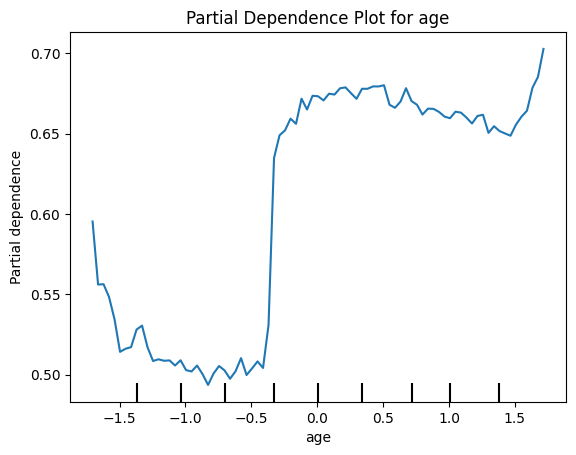

In [32]:
from sklearn.inspection import PartialDependenceDisplay

# Assuming 'models["Random Forest"]' is your trained model and 'X_test' is your test data
# You might need to adjust the feature name if it's different in your preprocessed data
feature_to_plot = 'age'

if feature_to_plot in X_test.columns:
    print(f"Generating PDP for '{feature_to_plot}' using scikit-learn...")
    PartialDependenceDisplay.from_estimator(
        models["Random Forest"],
        X_test,
        [feature_to_plot]
    )
    plt.title(f"Partial Dependence Plot for {feature_to_plot}")
    plt.show()
else:
    print(f"Feature '{feature_to_plot}' not found in X_test.")

In [22]:
!pip install --upgrade pdpbox

8. Comparative Analysis (ML vs DL Table)

In [21]:
# Combine ML + DL tables
final_results = pd.concat([results_df, dl_df])
print("\nFinal Comparative Performance (ML + DL in %):")
display(final_results)


Final Comparative Performance (ML + DL in %):


,accuracy,precision,recall,f1,roc_auc,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,67.03%,81.75%,66.99%,73.63%,74.01%,NaN,NaN,NaN,NaN,NaN
Decision Tree,62.74%,75.67%,67.48%,71.34%,59.90%,NaN,NaN,NaN,NaN,NaN
Random Forest,66.68%,78.27%,71.32%,74.63%,70.83%,NaN,NaN,NaN,NaN,NaN
SVM (Linear),47.96%,66.18%,49.67%,56.75%,47.79%,NaN,NaN,NaN,NaN,NaN
KNN,63.75%,78.49%,65.10%,71.17%,67.84%,NaN,NaN,NaN,NaN,NaN
XGBoost,70.65%,81.12%,74.68%,77.77%,75.75%,NaN,NaN,NaN,NaN,NaN
MLP,NaN,NaN,NaN,NaN,NaN,69.37%,82.61%,70.22%,75.91%,76.45%
CNN,NaN,NaN,NaN,NaN,NaN,69.49%,82.39%,70.73%,76.11%,76.74%
LSTM,NaN,NaN,NaN,NaN,NaN,69.40%,81.41%,71.89%,76.36%,75.64%
